<a href="https://colab.research.google.com/github/SithuminiNimthara/Research_Project/blob/main/shoreline_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics opencv-python-headless pandas matplotlib tqdm pyyaml --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00


In [3]:
import os

BASE_DIR = "/content/drive/MyDrive/Research"

# Dataset
ZIP_PATH = f"{BASE_DIR}/datasets/shoreline_seg_dataset.zip"
EXTRACT_DIR = f"{BASE_DIR}/shoreline_data/extracted"
TEST_FRAMES_DIR = f"{BASE_DIR}/shoreline_data/test_frames"

# YOLOv8 folders
VERSION = "yolov8"
RUN_NAME = "shoreline_seg_yolov8_v1"

RUNS_DIR = f"{BASE_DIR}/runs/{VERSION}"
MODELS_DIR = f"{BASE_DIR}/models/{VERSION}"
EVAL_DIR = f"{BASE_DIR}/evaluations/{VERSION}"

# Nest points
NEST_CSV = f"{BASE_DIR}/nest_points/nest_points.csv"

# Create folders if missing
os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print("✅ Paths ready")
print("ZIP_PATH      :", ZIP_PATH)
print("EXTRACT_DIR   :", EXTRACT_DIR)
print("RUNS_DIR      :", RUNS_DIR)
print("MODELS_DIR    :", MODELS_DIR)
print("EVAL_DIR      :", EVAL_DIR)
print("NEST_CSV      :", NEST_CSV)

✅ Paths ready
ZIP_PATH      : /content/drive/MyDrive/Research/datasets/shoreline_seg_dataset.zip
EXTRACT_DIR   : /content/drive/MyDrive/Research/shoreline_data/extracted
RUNS_DIR      : /content/drive/MyDrive/Research/runs/yolov8
MODELS_DIR    : /content/drive/MyDrive/Research/models/yolov8
EVAL_DIR      : /content/drive/MyDrive/Research/evaluations/yolov8
NEST_CSV      : /content/drive/MyDrive/Research/nest_points/nest_points.csv


Unzip dataset

In [4]:
!unzip -qo "{ZIP_PATH}" -d "{EXTRACT_DIR}"
!find "{EXTRACT_DIR}" -maxdepth 5 -name "data.yaml" -print

/content/drive/MyDrive/Research/shoreline_data/extracted/data.yaml


Set data.yaml

In [5]:
data_yaml = f"{EXTRACT_DIR}/data.yaml"

if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"❌ data.yaml not found: {data_yaml}")

print("✅ Found data.yaml:", data_yaml)

✅ Found data.yaml: /content/drive/MyDrive/Research/shoreline_data/extracted/data.yaml


Train YOLOv8 segmentation

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")   # YOLOv8 nano segmentation model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
model.train(
    data=data_yaml,
    epochs=80,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name=RUN_NAME,
    exist_ok=True
)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Research/shoreline_data/extracted/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shoreline_seg_yolov8_v1, nbs=64, nms=False, opset=None, optimize=False, op

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b354257a5d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [8]:
import os
import shutil

run_dir = f"{RUNS_DIR}/{RUN_NAME}"
best_pt = f"{run_dir}/weights/best.pt"
save_pt = f"{MODELS_DIR}/shoreline_seg_v8_best.pt"

if not os.path.exists(best_pt):
    raise FileNotFoundError(f"❌ best.pt not found: {best_pt}")

shutil.copy(best_pt, save_pt)

print("✅ Best YOLOv8 model saved to:", save_pt)
print("✅ Training run folder:", run_dir)

✅ Best YOLOv8 model saved to: /content/drive/MyDrive/Research/models/yolov8/shoreline_seg_v8_best.pt
✅ Training run folder: /content/drive/MyDrive/Research/runs/yolov8/shoreline_seg_yolov8_v1


Display training outputs

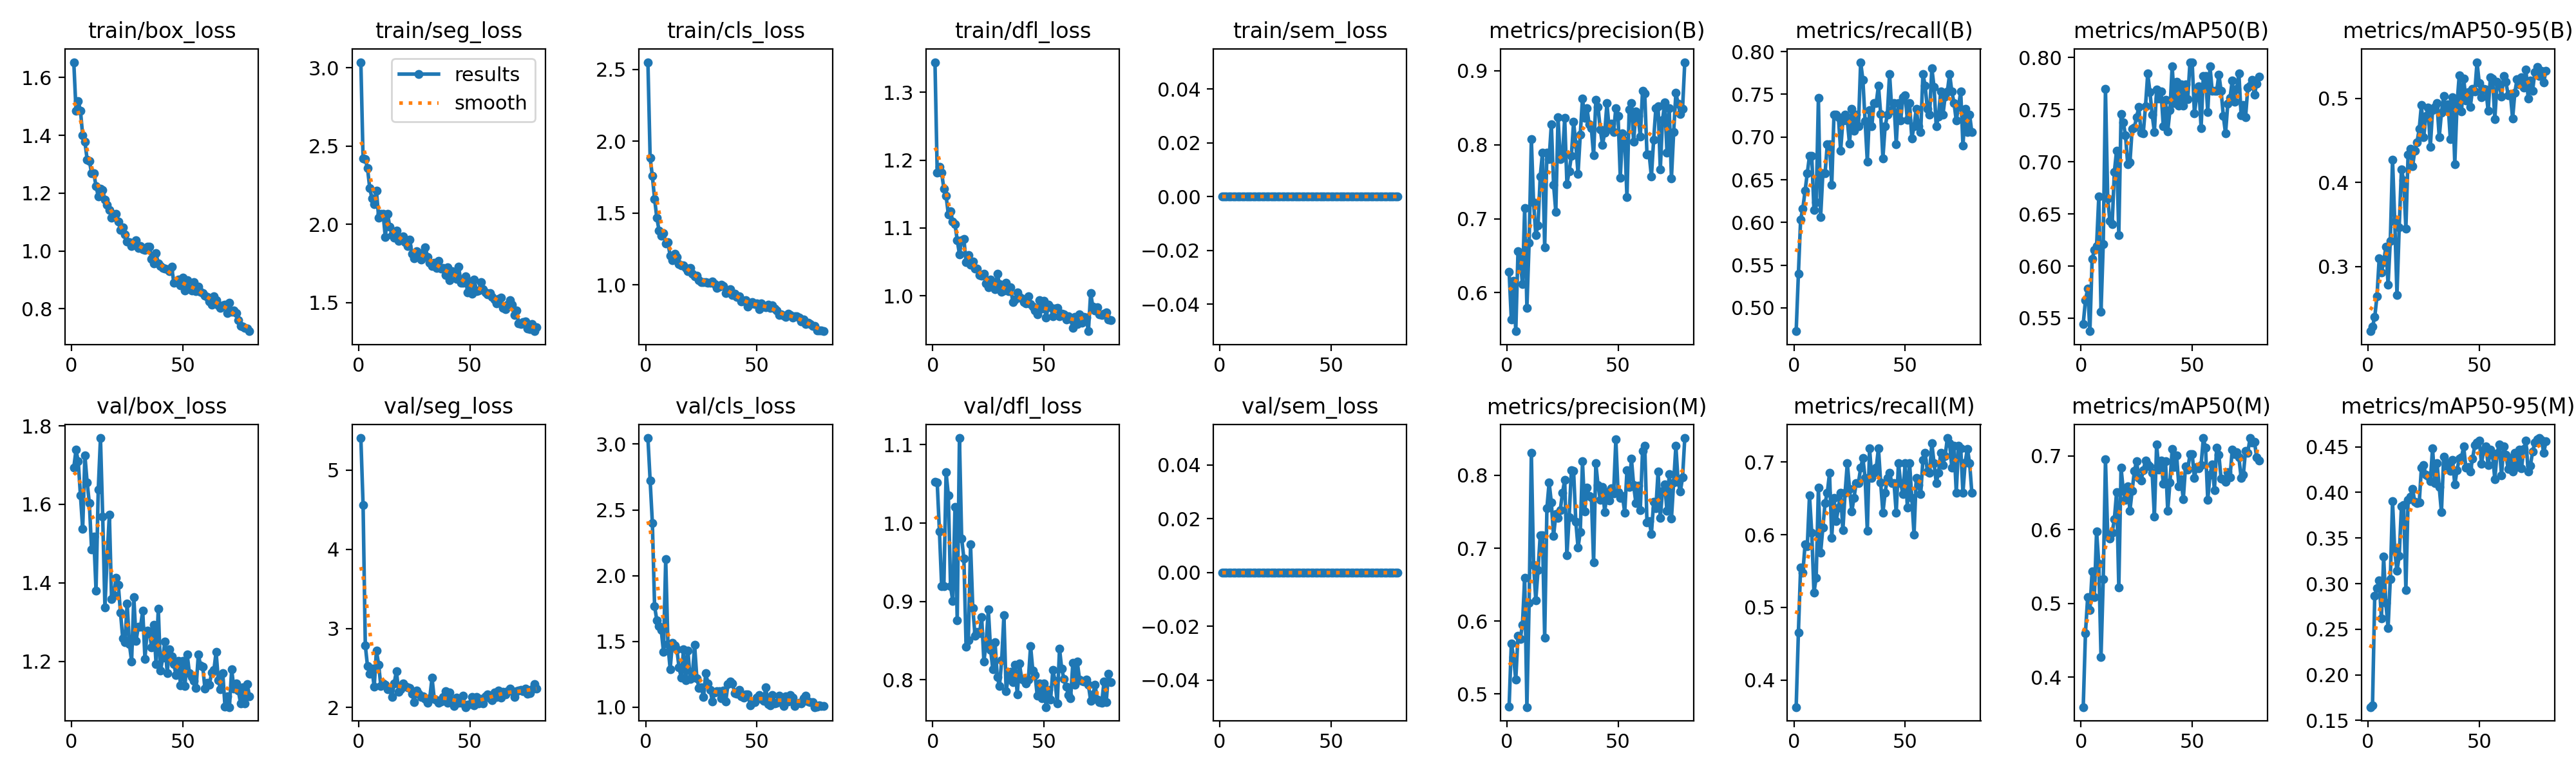

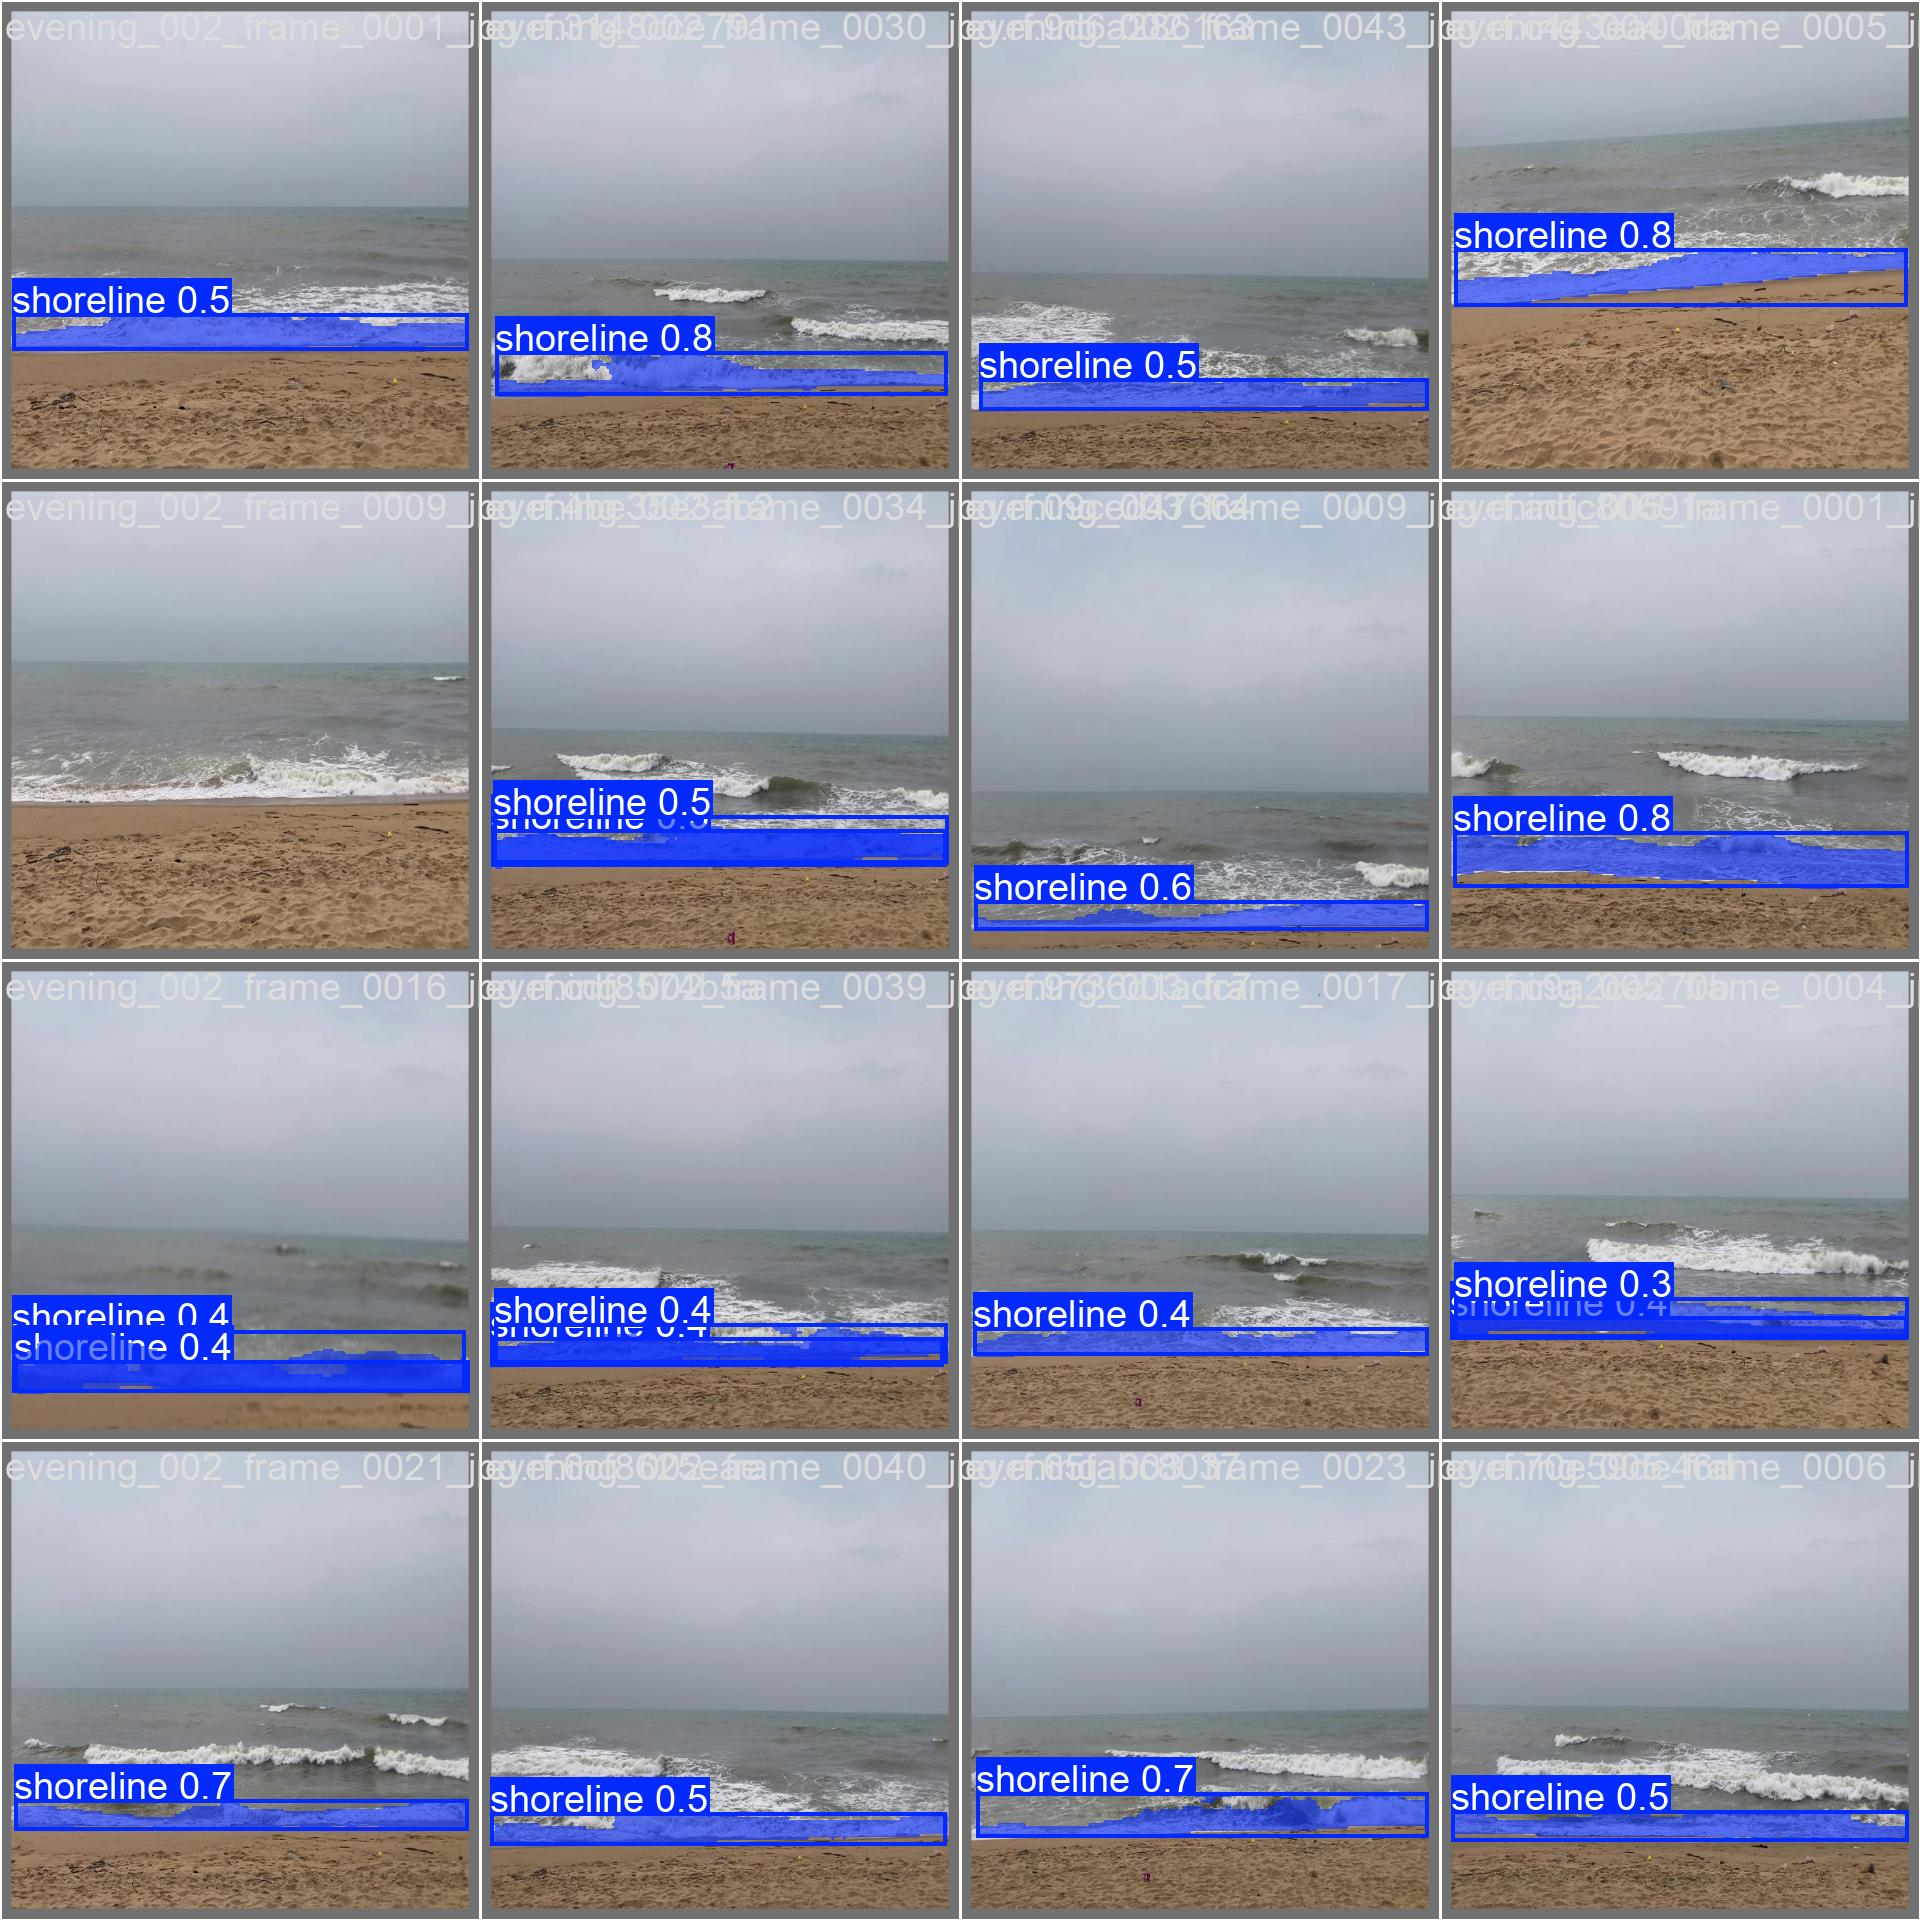

In [9]:
from IPython.display import Image, display

display(Image(filename=f"{run_dir}/results.png"))
display(Image(filename=f"{run_dir}/val_batch0_pred.jpg"))

Read training metrics

In [10]:
import pandas as pd

csv_path = f"{run_dir}/results.csv"
df8 = pd.read_csv(csv_path)

print("✅ Results file loaded")
print(df8.columns.tolist())

df8.head()

✅ Results file loaded
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
0,1,39.4772,1.65321,3.03649,2.55026,1.34413,0,0.62857,0.47260,0.54456,...,0.35962,0.16469,1.69366,5.40406,3.04598,1.05242,0,0.000656,0.000656,0.000656
1,2,71.5499,1.48580,2.41952,1.88354,1.18176,0,0.56367,0.53976,0.56739,...,0.45975,0.16687,1.73872,4.55873,2.72264,1.05204,0,0.001307,0.001307,0.001307
2,3,104.2180,1.51789,2.41626,1.75691,1.18968,0,0.61568,0.60350,0.57838,...,0.50906,0.28676,1.70941,2.78486,2.40207,0.98949,0,0.001940,0.001940,0.001940
3,4,136.7940,1.48553,2.35812,1.59876,1.18116,0,0.54800,0.61644,0.53751,...,0.49108,0.29490,1.62242,2.52132,1.76663,0.91970,0,0.001926,0.001926,0.001926
4,5,168.6840,1.39934,2.23128,1.46805,1.15783,0,0.65597,0.63699,0.60668,...,0.54338,0.30353,1.53775,2.42666,1.66278,0.91969,0,0.001901,0.001901,0.001901


Plot YOLOv8 metrics

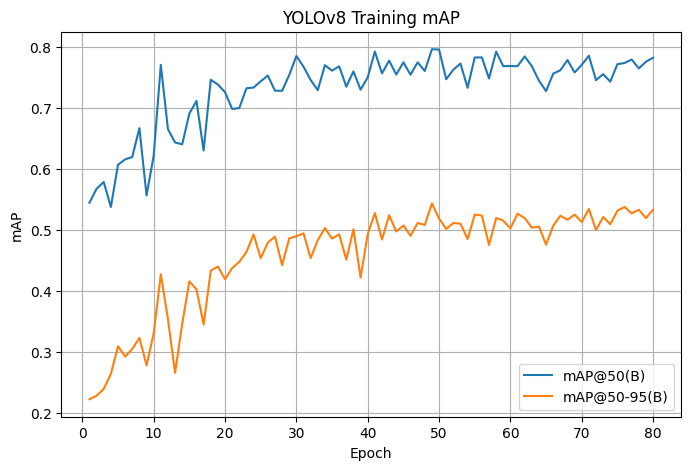

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

if "metrics/mAP50(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/mAP50(B)"], label="mAP@50(B)")
if "metrics/mAP50-95(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/mAP50-95(B)"], label="mAP@50-95(B)")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv8 Training mAP")
plt.legend()
plt.grid(True)
plt.show()

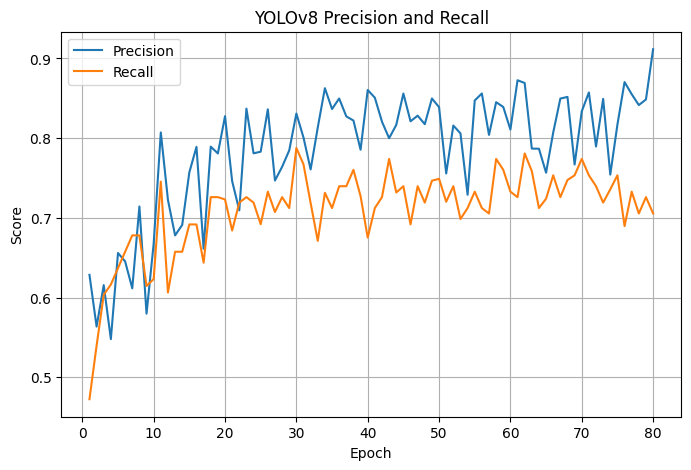

In [12]:
plt.figure(figsize=(8,5))

if "metrics/precision(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/precision(B)"], label="Precision")
if "metrics/recall(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv8 Precision and Recall")
plt.legend()
plt.grid(True)
plt.show()

Save plots into evaluations/yolov8/

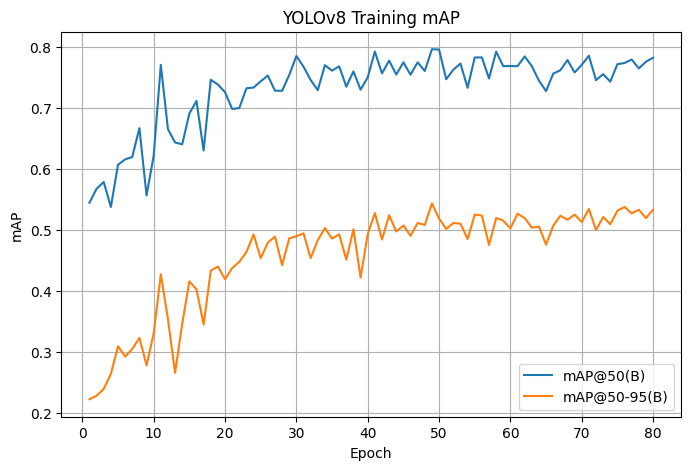

✅ Saved: /content/drive/MyDrive/Research/evaluations/yolov8/yolov8_map_curve.png


In [13]:
plt.figure(figsize=(8,5))

if "metrics/mAP50(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/mAP50(B)"], label="mAP@50(B)")
if "metrics/mAP50-95(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/mAP50-95(B)"], label="mAP@50-95(B)")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv8 Training mAP")
plt.legend()
plt.grid(True)

map_plot_path = f"{EVAL_DIR}/yolov8_map_curve.png"
plt.savefig(map_plot_path, bbox_inches="tight")
plt.show()

print("✅ Saved:", map_plot_path)

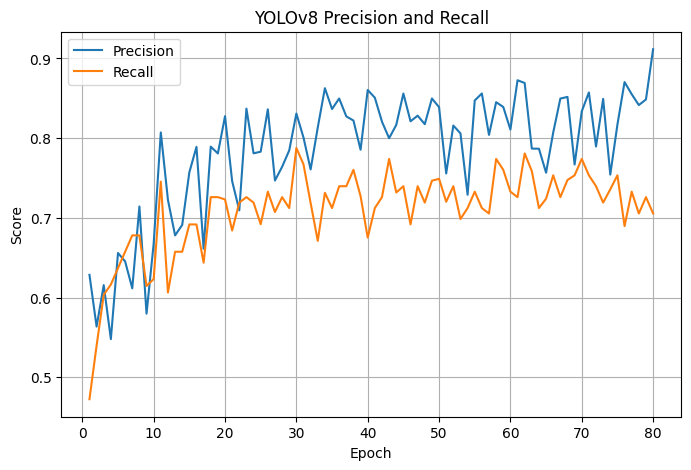

✅ Saved: /content/drive/MyDrive/Research/evaluations/yolov8/yolov8_precision_recall_curve.png


In [14]:
plt.figure(figsize=(8,5))

if "metrics/precision(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/precision(B)"], label="Precision")
if "metrics/recall(B)" in df8.columns:
    plt.plot(df8["epoch"], df8["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv8 Precision and Recall")
plt.legend()
plt.grid(True)

pr_plot_path = f"{EVAL_DIR}/yolov8_precision_recall_curve.png"
plt.savefig(pr_plot_path, bbox_inches="tight")
plt.show()

print("✅ Saved:", pr_plot_path)